# Train PointNet++ VAE on Synthetic Peptides



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import os
import glob

## Model Definition

In [2]:
def knn(x, k):
    inner = -2*torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    if idx is None:
        idx = knn(x, k=k)
    device = x.device
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1)*num_points
    idx = idx + idx_base
    idx = idx.view(-1)
    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size*num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims) 
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    feature = torch.cat((feature-x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class PointNetPlusPlusEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(6, 64, kernel_size=1, bias=False)
        self.conv2 = nn.Conv2d(128, 128, kernel_size=1, bias=False)
        self.conv3 = nn.Conv2d(256, 256, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv1d(448, 512, kernel_size=1, bias=False)
        self.bn4 = nn.BatchNorm1d(512)
        self.fc1 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        batch_size = x.size(0)
        x1 = get_graph_feature(x, k=20)
        x1 = F.relu(self.bn1(self.conv1(x1)))
        x1 = x1.max(dim=-1, keepdim=False)[0]
        x2 = get_graph_feature(x1, k=20)
        x2 = F.relu(self.bn2(self.conv2(x2)))
        x2 = x2.max(dim=-1, keepdim=False)[0]
        x3 = get_graph_feature(x2, k=20)
        x3 = F.relu(self.bn3(self.conv3(x3)))
        x3 = x3.max(dim=-1, keepdim=False)[0]
        x = torch.cat((x1, x2, x3), dim=1)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.adaptive_max_pool1d(x, 1).view(batch_size, -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class AdaptivePointDecoder(nn.Module):
    """
    Lightweight volumetric point cloud decoder with reduced parameters.
    Uses learned seed points + MLP refinement to generate variable numbers of points.
    """
    def __init__(self, latent_dim=128, num_seed_points=512):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_seed_points = num_seed_points
        
        # Reduced seed generator: 256 -> 512 (was 512 -> 1024)
        self.seed_generator = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, num_seed_points * 3)
        )
        
        # Reduced point refiner: 256 -> 128 (was 512 -> 512 -> 256 -> 128)
        self.point_refiner = nn.Sequential(
            nn.Conv1d(3 + latent_dim, 256, 1),
            nn.ReLU(),
            nn.Conv1d(256, 128, 1),
            nn.ReLU(),
            nn.Conv1d(128, 3, 1)
        )
        
        # Reduced upsampler: 128 -> 64 (was 256 -> 128)
        self.upsampler = nn.Sequential(
            nn.Conv1d(3 + latent_dim, 128, 1),
            nn.ReLU(),
            nn.Conv1d(128, 64, 1),
            nn.ReLU(),
            nn.Conv1d(64, 3, 1)
        )
        
    def forward(self, z, num_points=None):
        """
        Args:
            z: latent code [B, latent_dim]
            num_points: optional, number of points to generate (for inference)
        Returns:
            point cloud [B, 3, N]
        """
        batch_size = z.size(0)
        device = z.device
        
        # Generate initial seed points from latent code
        seed_points = self.seed_generator(z)  # [B, num_seed_points*3]
        seed_points = seed_points.view(batch_size, 3, self.num_seed_points)  # [B, 3, N_seed]
        
        # Expand latent to match seed points
        z_expanded = z.unsqueeze(2).repeat(1, 1, self.num_seed_points)  # [B, latent_dim, N_seed]
        
        # Refine seed points (volumetric refinement, not surface)
        refiner_input = torch.cat([seed_points, z_expanded], dim=1)  # [B, 3+latent_dim, N_seed]
        refined_points = seed_points + self.point_refiner(refiner_input)  # Residual
        
        # If we need more or fewer points than seed points
        if num_points is not None and num_points != self.num_seed_points:
            if num_points > self.num_seed_points:
                # Upsample: interpolate and add variation
                factor = num_points // self.num_seed_points
                remainder = num_points % self.num_seed_points
                
                # Repeat points
                upsampled = refined_points.repeat(1, 1, factor)  # [B, 3, N_seed*factor]
                
                # Add learned variation to avoid exact duplicates
                z_up = z.unsqueeze(2).repeat(1, 1, upsampled.size(2))
                up_input = torch.cat([upsampled, z_up], dim=1)
                variations = self.upsampler(up_input)
                upsampled = upsampled + 0.1 * variations  # Small variations
                
                # Handle remainder
                if remainder > 0:
                    extra = refined_points[:, :, :remainder]
                    z_extra = z.unsqueeze(2).repeat(1, 1, remainder)
                    extra_input = torch.cat([extra, z_extra], dim=1)
                    extra_var = self.upsampler(extra_input)
                    extra = extra + 0.1 * extra_var
                    upsampled = torch.cat([upsampled, extra], dim=2)
                
                return upsampled
            else:
                # Downsample: randomly sample subset
                indices = torch.randperm(self.num_seed_points, device=device)[:num_points]
                return refined_points[:, :, indices]
        
        return refined_points

class PointNetPlusPlusVAE(nn.Module):
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.encoder = PointNetPlusPlusEncoder(latent_dim)
        # Use adaptive decoder with seed points
        num_seed_points = min(512, num_points)  # Use fewer seeds, upsample as needed
        self.decoder = AdaptivePointDecoder(latent_dim, num_seed_points=num_seed_points)
        self.num_points = num_points
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x, num_points=None):
        """
        Args:
            x: input point cloud [B, 3, N]
            num_points: optional, for inference with variable point count
        """
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, num_points)
        return recon, mu, logvar
    
    def generate(self, z, num_points=None):
        """
        Generate point clouds from latent codes with variable point count.
        """
        return self.decoder(z, num_points)

print("Model defined with Lightweight AdaptivePointDecoder")
print("  - Reduced parameters (removed BatchNorm, narrower layers)")
print("  - Volumetric generation (not surface-only)")
print("  - Learned seed points + refinement")
print("  - Supports variable point counts")

Model defined with Lightweight AdaptivePointDecoder
  - Reduced parameters (removed BatchNorm, narrower layers)
  - Volumetric generation (not surface-only)
  - Learned seed points + refinement
  - Supports variable point counts


In [3]:
# Count model parameters
model_test = PointNetPlusPlusVAE(latent_dim=128, num_points=2000)

total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nEncoder parameters: {sum(p.numel() for p in model_test.encoder.parameters()):,}")
print(f"Decoder parameters: {sum(p.numel() for p in model_test.decoder.parameters()):,}")

# Show parameter breakdown by layer
print("\n--- Parameter Breakdown ---")
for name, param in model_test.named_parameters():
    print(f"{name:40s} {str(param.shape):20s} -> {param.numel():,} params")

Total parameters: 1,555,718
Trainable parameters: 1,555,718

Encoder parameters: 510,720
Decoder parameters: 1,044,998

--- Parameter Breakdown ---
encoder.conv1.weight                     torch.Size([64, 6, 1, 1]) -> 384 params
encoder.conv2.weight                     torch.Size([128, 128, 1, 1]) -> 16,384 params
encoder.conv3.weight                     torch.Size([256, 256, 1, 1]) -> 65,536 params
encoder.bn1.weight                       torch.Size([64])     -> 64 params
encoder.bn1.bias                         torch.Size([64])     -> 64 params
encoder.bn2.weight                       torch.Size([128])    -> 128 params
encoder.bn2.bias                         torch.Size([128])    -> 128 params
encoder.bn3.weight                       torch.Size([256])    -> 256 params
encoder.bn3.bias                         torch.Size([256])    -> 256 params
encoder.conv4.weight                     torch.Size([512, 448, 1]) -> 229,376 params
encoder.bn4.weight                       torch.Size([512])

## Dataset

## Chamfer Distance Loss

In [4]:
def chamfer_distance(p1, p2):
    """
    Calculate Chamfer Distance between two point clouds.
    This is permutation-invariant and suitable for unordered point clouds.
    
    Parameters:
        p1: tensor of shape (B, 3, N) - predicted point cloud
        p2: tensor of shape (B, 3, N) - ground truth point cloud
    Returns:
        Chamfer distance loss (scalar)
    """
    # Convert from (B, 3, N) to (B, N, 3) for distance calculation
    if p1.size(1) == 3: 
        p1 = p1.transpose(1, 2)  # [B, N, 3]
    if p2.size(1) == 3: 
        p2 = p2.transpose(1, 2)  # [B, N, 3]
        
    # Expand dimensions for pairwise distance computation
    # p1: [B, N, 1, 3], p2: [B, 1, M, 3]
    x = p1.unsqueeze(2)  # [B, N, 1, 3]
    y = p2.unsqueeze(1)  # [B, 1, M, 3]
    
    # Compute pairwise squared Euclidean distances
    # dist[b, i, j] = ||p1[b, i] - p2[b, j]||^2
    dist = torch.sum((x - y) ** 2, dim=-1)  # [B, N, M]
    
    # For each point in p1, find closest point in p2
    min_dist_p1_to_p2, _ = torch.min(dist, dim=2)  # [B, N]
    
    # For each point in p2, find closest point in p1
    min_dist_p2_to_p1, _ = torch.min(dist, dim=1)  # [B, M]
    
    # Chamfer distance: average of both directions
    chamfer_loss = torch.mean(min_dist_p1_to_p2) + torch.mean(min_dist_p2_to_p1)
    
    return chamfer_loss

print("Chamfer Distance loss function defined")
print("This loss is permutation-invariant and works with randomly sampled point clouds")

Chamfer Distance loss function defined
This loss is permutation-invariant and works with randomly sampled point clouds


In [5]:
from synthetic_peptides_dataset import SyntheticPeptidesDataset

class SyntheticPeptideDataset(SyntheticPeptidesDataset):
    def __init__(self, data_path, n_points=2000, num_data=None, **kw):
        super().__init__(data_path, target_num_points=n_points, num_files=num_data, **kw)
        self.n_points = n_points

    def __getitem__(self, idx):
        return super().__getitem__(idx)['points'].T  # [3, N]








































































































































































## Training

In [6]:
# Setup - Use GPU 1 (GPU 0 is busy)
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

lr = 5e-5
print(f"Learning rate: {lr}")

# Load training data
dataset = SyntheticPeptideDataset('./data/synthetic_peptides_split/train', n_points=2000, num_data=1000)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)

# Load validation data
val_dataset = SyntheticPeptideDataset('./data/synthetic_peptides_split/val', n_points=2000, num_data=213)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, drop_last=False)
print(f"Validation dataset: {len(val_dataset)} samples")

# Create model
model = PointNetPlusPlusVAE(latent_dim=128, num_points=2000).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=0)

# Configure BatchNorm
model.train()
for module in model.modules():
    if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
        module.momentum = 0.5

print("Setup complete")

Using device: cuda
Learning rate: 5e-05
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Selected files per structure:
  lamellar_sheets: 71/700
  micelles: 71/700
  nanofibers: 71/700
  nanotubes: 71/700
  random_aggregates: 714/7000
Dataset ready: 998 files, target_points=2000, normalize=True
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Selected files per structure:
  lamellar_sheets: 15/150
  micelles: 15/150
  nanofibers: 15/150
  nanotubes: 15/150
  random_aggregates: 152/1500
Dataset ready: 212 files, target_points=2000, normalize=True
Validation dataset: 212 samples
Setup complete


In [7]:
# Training loop with Chamfer Distance and Checkpointing
import json
from pathlib import Path

# Configuration
RUN_NAME = 'simulated_data_1000'  # Change this for different runs

# Create main checkpoint directory
checkpoint_dir = Path('checkpoints') / RUN_NAME
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Main checkpoint paths (for resuming)
checkpoint_path = checkpoint_dir / 'latest.pth'
best_checkpoint_path = checkpoint_dir / 'best.pth'
log_path = checkpoint_dir / 'training_log.json'

# Training configuration to save
config = {
    'max_files': len(dataset),
    'latent_dim': model.encoder.fc_mu.out_features,
    'n_points': dataset.n_points,
    'batch_size': dataloader.batch_size,
    'learning_rate': optimizer.param_groups[0]['lr'],
    'beta': 0.01,  # max KL weight
    'epochs': 500,
}

# Load checkpoint if exists
start_epoch = 0
losses = []
recon_losses = []
kl_losses = []
val_losses = []
val_recon_losses = []
val_kl_losses = []
best_loss = float('inf')

if checkpoint_path.exists():
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    losses = checkpoint['losses']
    recon_losses = checkpoint['recon_losses']
    kl_losses = checkpoint['kl_losses']
    val_losses = checkpoint.get('val_losses', [])
    val_recon_losses = checkpoint.get('val_recon_losses', [])
    val_kl_losses = checkpoint.get('val_kl_losses', [])
    best_loss = checkpoint.get('best_loss', min(losses) if losses else float('inf'))
    print(f"Resumed from epoch {start_epoch}, previous loss: {losses[-1]:.4f}, best loss: {best_loss:.4f}")
else:
    print(f"Starting fresh training: {RUN_NAME}")

epochs = config['epochs']
beta = config['beta']
save_every = 10  # Save checkpoint every N epochs
val_interval = 10  # Validate every N epochs

# LR scheduler + cyclic KL annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, epochs - start_epoch),
    eta_min=optimizer.param_groups[0]['lr'] * 0.1,
 )
kl_cycle = 50

try:
    for epoch in range(start_epoch, epochs):
        # Training phase
        model.train()
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0
        val_avg_loss = val_avg_recon = val_avg_kl = None  # Initialize validation variables
        
        # Cyclic KL weight: ramps 0 -> beta in half cycle, then stays at beta
        kl_beta = beta * min(1.0, 2.0 * (epoch % kl_cycle) / kl_cycle)
        
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(batch_data)
            
            # Use Chamfer Distance instead of MSE (permutation-invariant)
            recon_loss = chamfer_distance(recon_batch, batch_data)
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            total_loss = recon_loss + kl_beta * kl_loss
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        avg_recon = epoch_recon / len(dataloader)
        avg_kl = epoch_kl / len(dataloader)
        
        losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        # Validation phase (every val_interval epochs)
        if epoch % val_interval == 0:
            model.eval()
            val_epoch_loss = 0
            val_epoch_recon = 0
            val_epoch_kl = 0
            
            with torch.no_grad():
                for val_batch_data in val_dataloader:
                    val_batch_data = val_batch_data.to(device)
                    
                    val_recon_batch, val_mu, val_logvar = model(val_batch_data)
                    
                    val_recon_loss = chamfer_distance(val_recon_batch, val_batch_data)
                    val_kl_loss = -0.5 * torch.mean(1 + val_logvar - val_mu.pow(2) - val_logvar.exp())
                    val_total_loss = val_recon_loss + kl_beta * val_kl_loss
                    
                    val_epoch_loss += val_total_loss.item()
                    val_epoch_recon += val_recon_loss.item()
                    val_epoch_kl += val_kl_loss.item()
            
            val_avg_loss = val_epoch_loss / len(val_dataloader)
            val_avg_recon = val_epoch_recon / len(val_dataloader)
            val_avg_kl = val_epoch_kl / len(val_dataloader)
            
            val_losses.append(val_avg_loss)
            val_recon_losses.append(val_avg_recon)
            val_kl_losses.append(val_avg_kl)
        
            val_str = f'| Val: {val_avg_loss:.4f} (R:{val_avg_recon:.4f} K:{val_avg_kl:.4f})' if epoch % val_interval == 0 else ''
            print(
                f"Epoch {epoch:3d} | Train: {avg_loss:.4f} (R:{avg_recon:.4f} K:{avg_kl:.4f}) "
                f"| beta:{kl_beta:.4f} | lr:{optimizer.param_groups[0]['lr']:.2e} {val_str}"
            )
        
        # Save checkpoint
        if (epoch + 1) % save_every == 0 or epoch == epochs - 1:
            # Create epoch-specific folder
            epoch_folder = checkpoint_dir / f'checkpoint_epoch_{epoch+1}'
            epoch_folder.mkdir(exist_ok=True)
            
            epoch_checkpoint_path = epoch_folder / 'model.pth'
            epoch_log_path = epoch_folder / 'training_log.json'
            
            # Save epoch-specific checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'losses': losses,
                'recon_losses': recon_losses,
                'kl_losses': kl_losses,
                'val_losses': val_losses,
                'val_recon_losses': val_recon_losses,
                'val_kl_losses': val_kl_losses,
                'config': config,
                'best_loss': best_loss
            }, epoch_checkpoint_path)
            
            # Save epoch-specific JSON log
            with open(epoch_log_path, 'w') as f:
                json.dump({
                    'epoch': epoch,
                    'losses': losses,
                    'recon_losses': recon_losses,
                    'kl_losses': kl_losses,
                    'val_losses': val_losses,
                    'val_recon_losses': val_recon_losses,
                    'val_kl_losses': val_kl_losses,
                    'config': config,
                    'best_loss': best_loss
                }, f, indent=2)
            
            # Also save as latest (for easy resuming)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'losses': losses,
                'recon_losses': recon_losses,
                'kl_losses': kl_losses,
                'val_losses': val_losses,
                'val_recon_losses': val_recon_losses,
                'val_kl_losses': val_kl_losses,
                'config': config,
                'best_loss': best_loss
            }, checkpoint_path)
            
            with open(log_path, 'w') as f:
                json.dump({
                    'epoch': epoch,
                    'losses': losses,
                    'recon_losses': recon_losses,
                    'kl_losses': kl_losses,
                    'val_losses': val_losses,
                    'val_recon_losses': val_recon_losses,
                    'val_kl_losses': val_kl_losses,
                    'config': config,
                    'best_loss': best_loss
                }, f, indent=2)
            
        
        if epoch % val_interval == 0 and val_avg_loss < best_loss:
            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                torch.save({
                    'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(), 'losses': losses,
                    'recon_losses': recon_losses, 'kl_losses': kl_losses,
                    'val_losses': val_losses, 'val_recon_losses': val_recon_losses,
                    'val_kl_losses': val_kl_losses, 'config': config, 'best_loss': best_loss
                }, best_checkpoint_path)

        scheduler.step()

    final_val_str = f", Final Val: {val_losses[-1]:.4f}" if val_losses else ""
    print(f"\nTraining complete. Final Train: {losses[-1]:.4f}{final_val_str}, Best Val: {best_loss:.4f}")

except KeyboardInterrupt:
    print(f"\nInterrupted at epoch {epoch}. Saving...")
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'losses': losses,
        'recon_losses': recon_losses, 'kl_losses': kl_losses,
        'val_losses': val_losses, 'val_recon_losses': val_recon_losses,
        'val_kl_losses': val_kl_losses, 'config': config, 'best_loss': best_loss
    }, checkpoint_path)
    with open(log_path, 'w') as f:
        json.dump({'epoch': epoch, 'losses': losses, 'recon_losses': recon_losses,
                   'kl_losses': kl_losses, 'val_losses': val_losses,
                   'val_recon_losses': val_recon_losses, 'val_kl_losses': val_kl_losses,
                   'config': config, 'best_loss': best_loss}, f, indent=2)
    print(f"Saved. Resume from epoch {epoch + 1}")

except Exception as e:
    print(f"\nError at epoch {epoch}: {e}. Saving...")
    try:
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 'losses': losses,
            'recon_losses': recon_losses, 'kl_losses': kl_losses,
            'val_losses': val_losses, 'val_recon_losses': val_recon_losses,
            'val_kl_losses': val_kl_losses, 'config': config, 'best_loss': best_loss
        }, checkpoint_path)
        with open(log_path, 'w') as f:
            json.dump({'epoch': epoch, 'losses': losses, 'recon_losses': recon_losses,
                       'kl_losses': kl_losses, 'val_losses': val_losses,
                       'val_recon_losses': val_recon_losses, 'val_kl_losses': val_kl_losses,
                       'config': config, 'best_loss': best_loss}, f, indent=2)
        print(f"Checkpoint saved. Resume from epoch {epoch + 1}")
    except: pass

    raise

Loading checkpoint...
Resumed from epoch 500, previous loss: 0.0059, best loss: 0.0049

Training complete. Final Train: 0.0059, Final Val: 0.0062, Best Val: 0.0049


/tmp/ipykernel_121636/4049434272.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


## Visualize Training

/tmp/ipykernel_121636/3879413670.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


Loaded best checkpoint from epoch 450


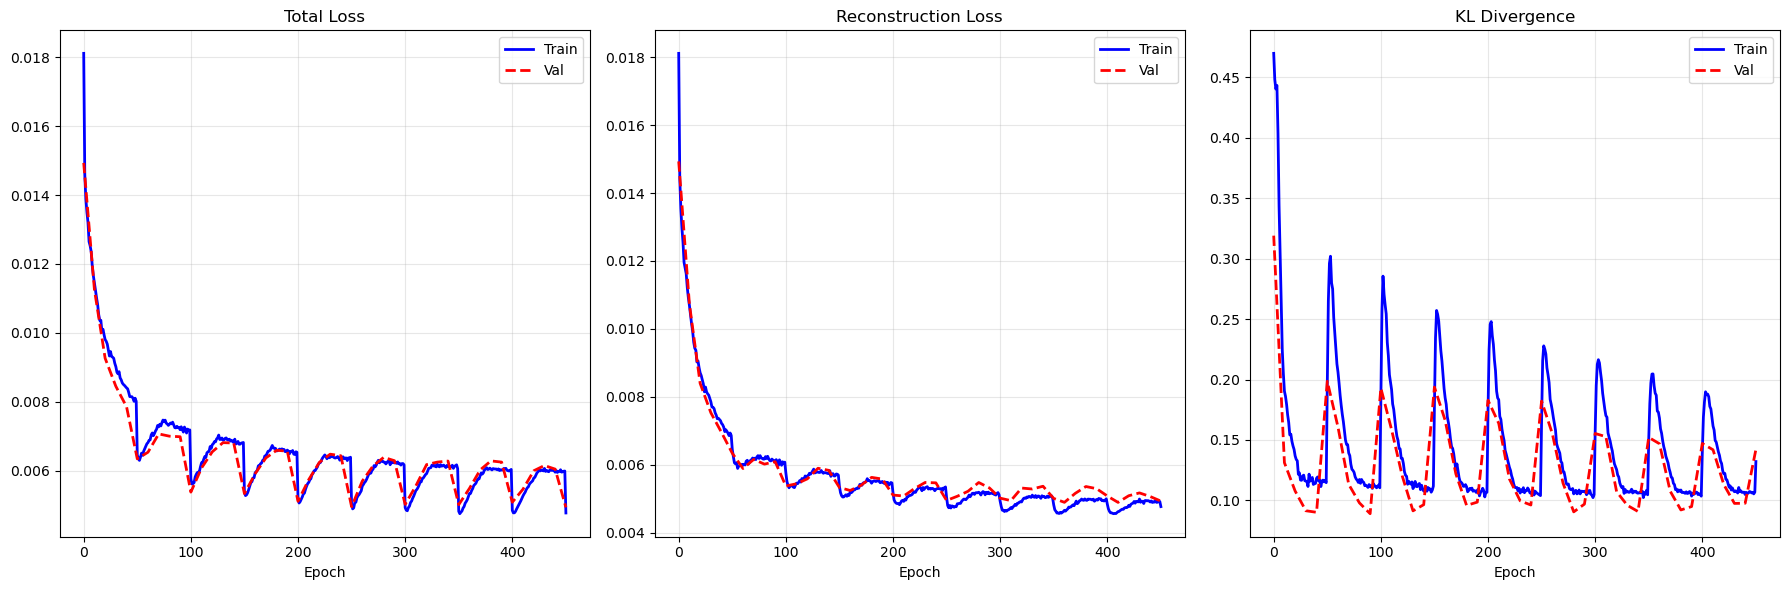


Run: simulated_data_1000
Training Progress:
  Epochs completed: 451
  Last epoch: 450
  Final train loss: 0.004768
  Final val loss: 0.004930
  Best val loss: 0.004930

Training Configuration:
  Dataset size: 998 files
  Latent dimension: 128
  Points per sample: 2000
  Batch size: 16
  Learning rate: 5e-05
  Beta (KL weight): 0.01


In [14]:
# Plot losses from checkpoint or log file
import json
from pathlib import Path

# Configuration
RUN_NAME = 'simulated_data_1000'  # Change this to match your training run
USE_BEST = True  # Set to False to use latest checkpoint instead

try:
    # Check in checkpoint directory
    checkpoint_dir = Path('checkpoints') / RUN_NAME
    
    if USE_BEST:
        checkpoint_path = checkpoint_dir / 'best.pth'
        checkpoint_type = "best"
    else:
        checkpoint_path = checkpoint_dir / 'latest.pth'
        checkpoint_type = "latest"
    
    log_path = checkpoint_dir / 'training_log.json'
    
    # Try checkpoint first (has optimizer state)
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        losses_data = checkpoint
        print(f"Loaded {checkpoint_type} checkpoint from epoch {checkpoint.get('epoch', 'N/A')}")
    elif log_path.exists():
        with open(log_path, 'r') as f:
            losses_data = json.load(f)
        print(f"Loaded from log file")
    else:
        raise FileNotFoundError(f"No checkpoint or log file found in checkpoints/{RUN_NAME} directory")
    
    # Check if validation losses exist
    has_val = 'val_losses' in losses_data and len(losses_data.get('val_losses', [])) > 0
    
    if has_val:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Training losses
        val_epochs = list(range(0, len(losses_data['losses']), 10))[:len(losses_data['val_losses'])]
        axes[0].plot(losses_data['losses'], 'b-', linewidth=2, label='Train')
        axes[0].plot(val_epochs, losses_data['val_losses'], 'r--', linewidth=2, label='Val')
        axes[0].set_title('Total Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(losses_data['recon_losses'], 'b-', linewidth=2, label='Train')
        axes[1].plot(val_epochs, losses_data['val_recon_losses'], 'r--', linewidth=2, label='Val')
        axes[1].set_title('Reconstruction Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(losses_data['kl_losses'], 'b-', linewidth=2, label='Train')
        axes[2].plot(val_epochs, losses_data['val_kl_losses'], 'r--', linewidth=2, label='Val')
        axes[2].set_title('KL Divergence')
        axes[2].set_xlabel('Epoch')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
    else:
        # Fallback to old style without validation
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        axes[0].plot(losses_data['losses'], 'b-', linewidth=2)
        axes[0].set_title('Total Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(losses_data['recon_losses'], 'r-', linewidth=2)
        axes[1].set_title('Reconstruction Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(losses_data['kl_losses'], 'g-', linewidth=2)
        axes[2].set_title('KL Divergence')
        axes[2].set_xlabel('Epoch')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    epoch_info = losses_data.get('epoch', len(losses_data['losses']) - 1)
    best_loss_info = losses_data.get('best_loss', 'N/A')
    
    print(f"\n{'='*60}")
    print(f"Run: {RUN_NAME}")
    print(f"{'='*60}")
    print(f"Training Progress:")
    print(f"  Epochs completed: {len(losses_data['losses'])}")
    print(f"  Last epoch: {epoch_info}")
    print(f"  Final train loss: {losses_data['losses'][-1]:.6f}")
    if has_val:
        print(f"  Final val loss: {losses_data['val_losses'][-1]:.6f}")
    if best_loss_info != 'N/A':
        print(f"  Best {'val' if has_val else 'train'} loss: {best_loss_info:.6f}")
    
    # Display training configuration if available
    if 'config' in losses_data:
        config = losses_data['config']
        print(f"\nTraining Configuration:")
        print(f"  Dataset size: {config.get('max_files', 'N/A')} files")
        print(f"  Latent dimension: {config.get('latent_dim', 'N/A')}")
        print(f"  Points per sample: {config.get('n_points', 'N/A')}")
        print(f"  Batch size: {config.get('batch_size', 'N/A')}")
        print(f"  Learning rate: {config.get('learning_rate', 'N/A')}")
        print(f"  Beta (KL weight): {config.get('beta', 'N/A')}")
    print(f"{'='*60}")
    

except FileNotFoundError as e:
    print(f"Error: {e}. Train first.")

## Test Reconstruction

In [19]:
# Test reconstruction using saved model
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# Configuration
RUN_NAME = 'simulated_data_try4'  # Change this to match your training run
USE_BEST = True  # Set to False to use latest checkpoint instead

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PointNetPlusPlusVAE(latent_dim=128, num_points=2000).to(device)

if USE_BEST:
    checkpoint_path = Path('checkpoints') / RUN_NAME / 'best.pth'
    checkpoint_type = "best"
else:
    checkpoint_path = Path('checkpoints') / RUN_NAME / 'latest.pth'
    checkpoint_type = "latest"

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded {checkpoint_type} model from run: {RUN_NAME}")
print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"  Best loss: {checkpoint.get('best_loss', 'N/A'):.6f}")

# Load samples
structure_types = ['nanotubes', 'micelles', 'nanofibers', 'random_aggregates', 'lamellar_sheets']
samples = {}

for struct_type in structure_types:
    files = glob.glob(f'./data/synthetic_peptides/{struct_type}/*.gro')
    if files:
        lines = open(files[0]).readlines()
        points = np.array([[float(line.split()[i]) for i in [-3,-2,-1]] 
                          for line in lines[2:-1] if len(line.split()) >= 6])
        
        # Sample and normalize
        idx = np.random.choice(len(points), 2000, replace=len(points)<2000)
        points = points[idx]
        points = points - points.mean(0)
        points = points / np.max(np.linalg.norm(points, axis=1))
        
        samples[struct_type] = torch.tensor(points.T, dtype=torch.float32).unsqueeze(0).to(device)

# Create visualization
subplot_titles = []
for s in structure_types:
    subplot_titles.extend([f'{s} (Original)', f'{s} (Reconstructed)'])

fig = make_subplots(rows=5, cols=2, specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]] * 5,
                    subplot_titles=subplot_titles)

with torch.no_grad():
    for i, struct_type in enumerate(structure_types, 1):
        if struct_type in samples:
            test_sample = samples[struct_type]
            recon, _, _ = model(test_sample)
            
            original = test_sample.squeeze().cpu().numpy().T
            reconstructed = recon.squeeze().cpu().numpy().T
            
            # Original and reconstructed
            fig.add_trace(go.Scatter3d(x=original[:,0], y=original[:,1], z=original[:,2],
                                     mode='markers', marker=dict(size=1.5, color='blue', opacity=0.6),
                                     showlegend=False), row=i, col=1)
            fig.add_trace(go.Scatter3d(x=reconstructed[:,0], y=reconstructed[:,1], z=reconstructed[:,2],
                                     mode='markers', marker=dict(size=1.5, color='red', opacity=0.6),
                                     showlegend=False), row=i, col=2)
            
            cd = chamfer_distance(recon, test_sample).item()
            print(f"{struct_type:15s} CD: {cd:.6f}")

fig.update_layout(height=1600, width=1200, title_text="VAE Reconstruction Test")
fig.write_image(f"{RUN_NAME}_reconstruction.png")
print(f"\n✅ Saved visualization to '{RUN_NAME}_reconstruction.png'")
fig.show()

/tmp/ipykernel_4090858/1558652729.py:21: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Loaded best model from run: simulated_data_try4
  Epoch: 300
  Best loss: 0.012649
nanotubes       CD: 0.027853
micelles        CD: 0.109315
nanofibers      CD: 0.062502
random_aggregates CD: 0.082409
lamellar_sheets CD: 0.069659

✅ Saved visualization to 'simulated_data_try4_reconstruction.png'


In [17]:



# Demo: Variable Point Count Generation
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("=== Testing Variable Point Count Generation ===\n")

# Load a test model (or use existing one)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_model = PointNetPlusPlusVAE(latent_dim=128, num_points=2000).to(device)
test_model.eval()

# Load a sample peptide
files = glob.glob('./data/synthetic_peptides/nanotubes/*.gro')
if files:
    lines = open(files[0]).readlines()
    points = np.array([[float(line.split()[i]) for i in [-3,-2,-1]] 
                      for line in lines[2:-1] if len(line.split()) >= 6])
    idx = np.random.choice(len(points), 2000, replace=len(points)<2000)
    points = points[idx]
    points = points - points.mean(0)
    points = points / np.max(np.linalg.norm(points, axis=1))
    test_input = torch.tensor(points.T, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate with different point counts
    point_counts = [256, 512, 1000, 2000, 4000]
    
    print("Generating reconstructions with different point counts:")
    with torch.no_grad():
        # Get latent code
        mu, logvar = test_model.encoder(test_input)
        z = test_model.reparameterize(mu, logvar)
        
        fig = make_subplots(
            rows=1, cols=len(point_counts), 
            specs=[[{'type': 'scatter3d'}] * len(point_counts)],
            subplot_titles=[f'{n} points' for n in point_counts]
        )
        
        for i, num_points in enumerate(point_counts, 1):
            # Generate with specific point count
            recon = test_model.generate(z, num_points=num_points)
            points_np = recon.squeeze().cpu().numpy().T
            
            print(f"  {num_points:5d} points: shape {recon.shape}")
            
            # Add to plot
            fig.add_trace(
                go.Scatter3d(
                    x=points_np[:,0], 
                    y=points_np[:,1], 
                    z=points_np[:,2],
                    mode='markers', 
                    marker=dict(size=2, color='red', opacity=0.6),
                    showlegend=False
                ), 
                row=1, col=i
            )
        
        fig.update_layout(
            height=400, 
            width=2000, 
            title_text="Same Nanotube Reconstructed with Different Point Counts"
        )
        fig.show()
        
    print("\n✅ Variable point count generation working!")
    print(f"   Decoder has {test_model.decoder.num_seed_points} seed points")
    print(f"   Can generate any number of points via up/downsampling")
else:
    print("No test data found. Load data first.")

=== Testing Variable Point Count Generation ===

Generating reconstructions with different point counts:
    256 points: shape torch.Size([1, 3, 256])
    512 points: shape torch.Size([1, 3, 512])
   1000 points: shape torch.Size([1, 3, 1000])
   2000 points: shape torch.Size([1, 3, 2000])
   4000 points: shape torch.Size([1, 3, 4000])



✅ Variable point count generation working!
   Decoder has 512 seed points
   Can generate any number of points via up/downsampling


--- Overfitting Test ---
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Dataset ready: 5 files, target_points=2000, normalize=True
Overfitting on 5 samples.
✅ Dropout disabled for overfitting test

Starting overfitting training loop...
Epoch   0 | Overfit Loss: 0.019222
Epoch  20 | Overfit Loss: 0.017257
Epoch  40 | Overfit Loss: 0.014852
Epoch  60 | Overfit Loss: 0.013282
Epoch  80 | Overfit Loss: 0.011736
Epoch 100 | Overfit Loss: 0.010705
Epoch 120 | Overfit Loss: 0.011664
Epoch 140 | Overfit Loss: 0.011327
Epoch 160 | Overfit Loss: 0.011110
Epoch 180 | Overfit Loss: 0.011538
Epoch 200 | Overfit Loss: 0.007999
Epoch 220 | Overfit Loss: 0.008114
Epoch 240 | Overfit Loss: 0.006822
Epoch 260 | Overfit Loss: 0.006775
Epoch 280 | Overfit Loss: 0.006394
Epoch 300 | Overfit Loss: 0.006260
Epoch 320 | Overfit Loss: 0.005767
Epoch 340 | Overfit Loss: 0.005494
Epoch 360 | Overfit Loss: 0

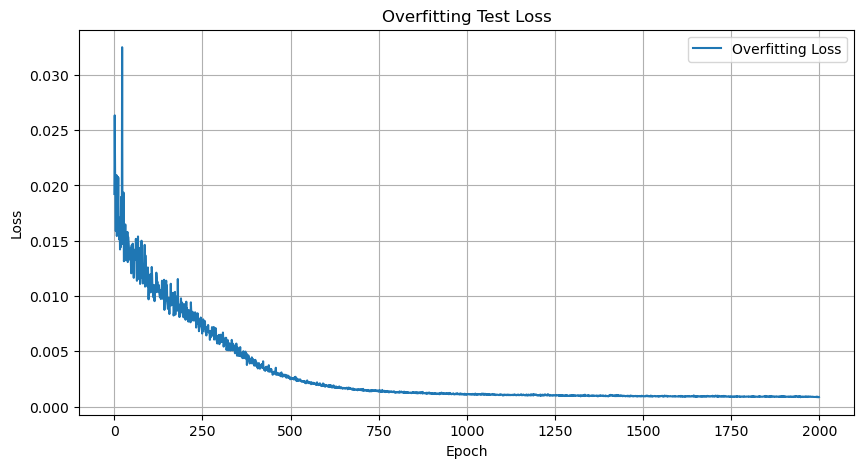

In [21]:
def disable_dropout(model):
    """
    Disables dropout layers in the model for the overfitting test.
    """
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = 0
    print("✅ Dropout disabled for overfitting test")
    return model
# Overfitting Test
print("--- Overfitting Test ---")

N_POINTS = 2000
BATCH_SIZE = 5
LATENT_DIM = 128
LEARNING_RATE = 5e-5


# 1. Create a small dataset (e.g., one batch)
overfit_dataset = SyntheticPeptideDataset(data_path='./data/synthetic_peptides_split/train', n_points=N_POINTS, num_data=BATCH_SIZE)
overfit_dataloader = DataLoader(overfit_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Overfitting on {len(overfit_dataset)} samples.")

# 2. Create a new model instance
overfit_model = PointNetPlusPlusVAE(latent_dim=LATENT_DIM, num_points=N_POINTS).to(device)

# 3. Disable dropout
overfit_model = disable_dropout(overfit_model)

# 4. Create a new optimizer
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=LEARNING_RATE)

# 5. Training loop for overfitting
overfit_epochs = 2000
overfit_losses = []
beta_overfit = 0 # No KL divergence for this test

print("\nStarting overfitting training loop...")
for epoch in range(overfit_epochs):
    for batch_data in overfit_dataloader:
        batch_data = batch_data.to(device)
        
        overfit_optimizer.zero_grad()
        recon_batch, mu, logvar = overfit_model(batch_data)
        
        recon_loss = chamfer_distance(recon_batch, batch_data)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        total_loss = recon_loss + beta_overfit * kl_loss
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(overfit_model.parameters(), max_norm=1.0)
        overfit_optimizer.step()
        
    overfit_losses.append(total_loss.item())
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Overfit Loss: {total_loss.item():.6f}')

print(f"\n✅ Overfitting test complete! Final loss: {overfit_losses[-1]:.6f}")
# A successful test should show the loss approaching zero.

# Plot the overfitting loss
plt.figure(figsize=(10, 5))
plt.plot(overfit_losses, label='Overfitting Loss')
plt.title('Overfitting Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Visualize a specific sample from the overfitted reconstruction
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== CHANGE THIS INDEX TO VIEW DIFFERENT SAMPLES (0-4) =====
SAMPLE_INDEX = 1
# ==============================================================

for SAMPLE_INDEX in range(5):
    # Get all samples from the overfit dataloader
    overfit_sample = next(iter(overfit_dataloader)).to(device)

    # Reconstruct with the overfitted model
    overfit_model.eval() # Set to evaluation mode
    with torch.no_grad():
        recon_overfit, _, _ = overfit_model(overfit_sample)

    # Extract the specific sample
    original_overfit = overfit_sample[SAMPLE_INDEX].cpu().numpy().T  # [N, 3]
    recon_overfit_np = recon_overfit[SAMPLE_INDEX].cpu().numpy().T    # [N, 3]

    # Get the structure type from the filename
    sample_file = overfit_dataset.files[SAMPLE_INDEX]
    structure_type = sample_file.split('/')[-2]  # Extract folder name (e.g., 'nanotubes', 'micelles')

    # Create visualization
    fig_overfit = make_subplots(
        rows=1, cols=2, 
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=[f'{structure_type.title()} - Original', f'{structure_type.title()} - Reconstructed']
    )

    # Original point cloud
    fig_overfit.add_trace(
        go.Scatter3d(
            x=original_overfit[:,0], 
            y=original_overfit[:,1], 
            z=original_overfit[:,2],
            mode='markers', 
            marker=dict(size=2, color='blue', opacity=0.7),
            showlegend=False
        ), 
        row=1, col=1
    )

    # Reconstructed point cloud
    fig_overfit.add_trace(
        go.Scatter3d(
            x=recon_overfit_np[:,0], 
            y=recon_overfit_np[:,1], 
            z=recon_overfit_np[:,2],
            mode='markers', 
            marker=dict(size=2, color='red', opacity=0.7),
            showlegend=False
        ), 
        row=1, col=2
    )

    fig_overfit.update_layout(
        height=500, 
        width=1200, 
        title_text=f"Overfitting Test: {structure_type.title()} Reconstruction"
    )
    fig_overfit.show()

    # Save the figure as PNG with structure type name
    fig_overfit.write_image(f"{structure_type}_reconstruction_overfit.png")
    print(f"✅ Saved PNG snapshot to '{structure_type}_reconstruction_overfit.png'")

    # Calculate and print Chamfer Distance for this sample
    cd_sample = chamfer_distance(recon_overfit[SAMPLE_INDEX:SAMPLE_INDEX+1], overfit_sample[SAMPLE_INDEX:SAMPLE_INDEX+1]).item()
    print(f"{structure_type.title()} - Chamfer Distance: {cd_sample:.6f}")

    # Print all sample CDs for reference with their structure types
    print(f"\nAll {overfit_sample.shape[0]} samples Chamfer Distances:")
    for i in range(overfit_sample.shape[0]):
        cd = chamfer_distance(recon_overfit[i:i+1], overfit_sample[i:i+1]).item()
        struct_type = overfit_dataset.files[i].split('/')[-2]
        marker = " <-- Current" if i == SAMPLE_INDEX else ""
        print(f"  Sample {i+1} ({struct_type}): {cd:.6f}{marker}")


✅ Saved PNG snapshot to 'random_aggregates_reconstruction_overfit.png'
Random_Aggregates - Chamfer Distance: 0.000733

All 5 samples Chamfer Distances:
  Sample 1 (random_aggregates): 0.000733 <-- Current
  Sample 2 (nanotubes): 0.001151
  Sample 3 (lamellar_sheets): 0.000965
  Sample 4 (random_aggregates): 0.000572
  Sample 5 (nanotubes): 0.001035


✅ Saved PNG snapshot to 'nanotubes_reconstruction_overfit.png'
Nanotubes - Chamfer Distance: 0.001059

All 5 samples Chamfer Distances:
  Sample 1 (random_aggregates): 0.000717
  Sample 2 (nanotubes): 0.001059 <-- Current
  Sample 3 (lamellar_sheets): 0.000931
  Sample 4 (random_aggregates): 0.000618
  Sample 5 (nanotubes): 0.001062


✅ Saved PNG snapshot to 'lamellar_sheets_reconstruction_overfit.png'
Lamellar_Sheets - Chamfer Distance: 0.000921

All 5 samples Chamfer Distances:
  Sample 1 (random_aggregates): 0.000745
  Sample 2 (nanotubes): 0.001072
  Sample 3 (lamellar_sheets): 0.000921 <-- Current
  Sample 4 (random_aggregates): 0.000542
  Sample 5 (nanotubes): 0.000990


✅ Saved PNG snapshot to 'random_aggregates_reconstruction_overfit.png'
Random_Aggregates - Chamfer Distance: 0.000570

All 5 samples Chamfer Distances:
  Sample 1 (random_aggregates): 0.000752
  Sample 2 (nanotubes): 0.001055
  Sample 3 (lamellar_sheets): 0.000963
  Sample 4 (random_aggregates): 0.000570 <-- Current
  Sample 5 (nanotubes): 0.001054


✅ Saved PNG snapshot to 'nanotubes_reconstruction_overfit.png'
Nanotubes - Chamfer Distance: 0.001052

All 5 samples Chamfer Distances:
  Sample 1 (random_aggregates): 0.000787
  Sample 2 (nanotubes): 0.001056
  Sample 3 (lamellar_sheets): 0.000971
  Sample 4 (random_aggregates): 0.000758
  Sample 5 (nanotubes): 0.001052 <-- Current
